RNN - Erro dos pesos computados e usado somente durante a iteração

In [1]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from Testing.RTLO import *


In [90]:
def f(x):
    return np.tanh(x)
def d_f(x):
    return 1/np.cosh(10*np.tanh(x/10))**2  # the tanh prevents oveflow

class RTLO:
    def __init__(self, nIN, nHS, nOUT,ηS=[0.1,0.1,0.1], τ=10,decay=1e-5):
        np.random.seed(42)
        self.nIN = nIN
        self.nHS = nHS
        self.nOUT = nOUT
        self.ΔOUT = np.zeros((nOUT, nHS))
        self.ΔHS = np.zeros((nHS, nHS))
        self.ΔIN = np.zeros((nHS, nIN))
        self.xI = np.zeros(nIN)
        self.ηS = np.array(ηS)
        self.τ = τ
        self.h0 = 0
        self.hI = np.zeros(nHS)
        self.hF = np.zeros(nHS)
        self.ht = np.zeros(nHS)
        self.k = 0
        self.u = None
        self.decay = decay
        self.wIN = 0.1*(np.random.rand(nHS, nIN) - 1)
        self.wHS = 1.5*np.random.randn(nHS, nHS)/nHS**0.5
        self.wOUT = 0.1*(2*np.random.rand(nOUT, nHS) - 1)/nHS**0.5
        self.b = np.random.randn(nHS, nOUT)/nOUT**0.5
        self.p = np.zeros((self.nHS, self.nHS))
        self.q = np.zeros((self.nHS, self.nIN))
        self.wIN = self.xavier_uniform([nHS, nIN])
        self.wHS = self.xavier_uniform([nHS, nHS])
        self.wOUT = self.xavier_uniform([nOUT, nHS])
        self.b = np.random.randn(nHS, nOUT)/nOUT**0.5

    def fit(self, x, y, tip=1):
        self.ηS = self.ηS/(1 + self.decay*self.k)
        η1,η2,η3 = self.ηS
        self.u = np.dot(self.nHS,self.hI) + np.dot(self.wIN,x)
        self.hF = self.hI + (1/self.τ)*(-self.hI + f(self.u))
        yP = np.dot(self.wOUT, self.hF)
        e = y - yP
        self.p = np.outer(d_f(self.u),self.hI)/self.τ + (1-1/self.τ)*self.p
        self.q = np.outer(d_f(self.u),self.xI)/self.τ + (1-1/self.τ)*self.q
        δOUT = η1*np.outer(e,self.hF)
        δHS = η2*np.outer(np.dot(self.b, e),np.ones(self.nHS))*self.p
        δIN = η3*np.outer(np.dot(self.b, e),np.ones(self.nIN))*self.q

        self.ΔOUT = (self.ΔOUT*self.k/(self.k+1)) + (δOUT/(self.k+1))
        self.ΔHS = (self.ΔHS*self.k/(self.k+1)) + (δHS/(self.k+1))
        self.ΔIN =  (self.ΔIN*self.k/(self.k+1)) + (δIN/(self.k+1))

        self.wIN = self.wIN + self.ΔIN * tip
        self.wHS = self.wHS + self.ΔHS * tip
        self.wOUT = self.wOUT + self.ΔOUT * tip

        self.hI = self.hF
        self.ht = self.hF
        self.ht2 = self.hF
        self.xI = x

    def PredSingle(self,x):
        u = np.dot(self.wHS, self.ht) + np.dot(self.wIN, x)
        h = self.ht + (-self.ht + f(u))/self.τ
        y = np.dot(self.wOUT, h)
        self.ht = h
        return y
    
    def PredMulti(self,x,Thrs,stps):
        xCopy = x.copy()
        yV = np.array([])
        i = 0
        while xCopy[-1] > Thrs:
            u = np.dot(self.wHS, self.ht) + np.dot(self.wIN, xCopy)
            h = self.ht + (-self.ht + f(u))/self.τ
            y = np.dot(self.wOUT, h)
            xCopy = np.append(xCopy,y[-1])
            xCopy = np.delete(xCopy,0)
            yV = np.append(yV,y[-1])
            self.ht = h
            i = i+1
            if i==stps: break
        return yV
    
    def restore(self):
        self.ht = self.hF
        self.ht2 = self.hF
    
    def xavier_uniform(self,shape):
        np.random.seed(42)
        n_in, n_out = shape
        limit = np.sqrt(6 / (n_in + n_out))
        return np.random.uniform(-limit, limit, size=shape)


In [3]:
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
n,nIN,nOUT,nHS=4,3,3,3

sig = df['PC1'].values
hi = np.array([sig[i:n+i] for i in range(len(sig)-n+1)])
X = np.array([hi[i][:nIN] for i in range(len(hi))])
Y = np.array([hi[i][-nOUT:] for i in range(len(hi))])

In [4]:
yR,yP = np.array([]),np.array([])
xR = np.array([])
yV = []
xV=[]
i = 0
rtlo = RTLO(nIN,nHS,nOUT)
for x,y in zip(X,Y):
    y_p = rtlo.PredSingle(x)
    rtlo.restore()
    y_v = rtlo.PredMulti(x,Thrs=0.2,stps=len(X))
    rtlo.restore()
    rtlo.fit(x,y)
    yR = np.append(yR,y[-1])
    yP = np.append(yP,y_p[-1])
    yV.append(y_v)
    x_v = np.arange(len(y_v)) + i
    xV.append(x_v)
    xR = np.append(xR,i)
    i = i+1

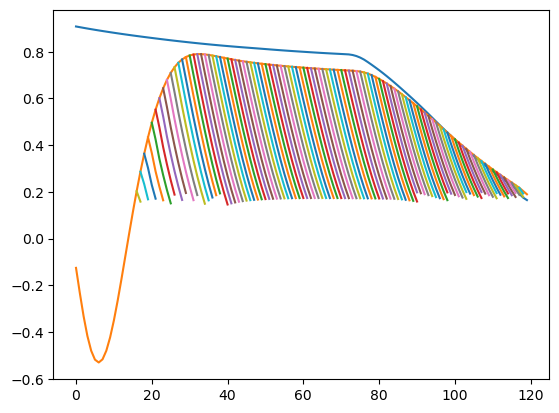

In [5]:
plt.plot(xR,yR)
plt.plot(xR,yP)
for x,y in zip(xV,yV):
    plt.plot(x,y,label=f'{i+1}')